# 06 · From Tree to Forest

The bridge to the ensembles project. Take the two problems a single greedy tree handled badly — XOR (it stalled) and noisy blobs (it memorized) — and show that a **forest** of trees recovers both. Then: what `max_depth`, `min_samples_leaf`, and `criterion` actually do, and a warning that a tree's own importances are biased.

**Artifacts:** `outputs/figures/06_*.png`, `outputs/data/06_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from src.config import load_settings
from src.datasets import xor, noisy_blobs, moons
from src.tree.classifier import DecisionTreeClassifier
from src.evaluation import accuracy, plot_decision_boundary, tree_vs_forest
from src.outputs import save_figure, save_json

cfg = load_settings()
SEED, N_TREES, RES = cfg.seed, cfg.forest.n_estimators, 180

## A forest solves XOR that one greedy tree could not
Each tree sees a resampled subset and a random subset of features, so the ensemble explores splits a single greedy path misses.

PosixPath('/workspaces/decision_trees_101/outputs/figures/06_tree_vs_forest_xor.png')

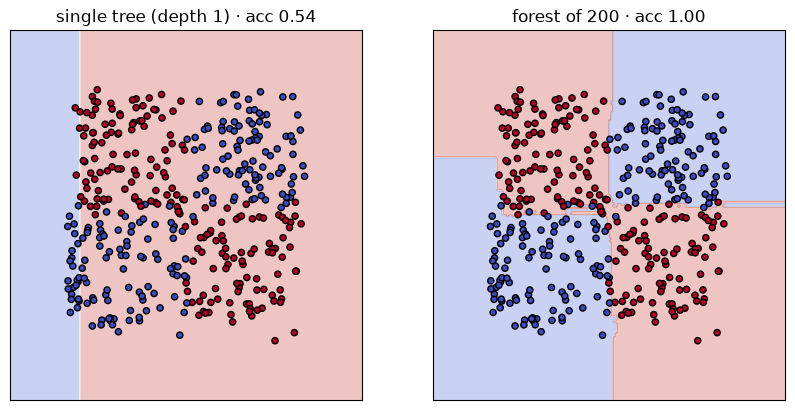

In [2]:
Xx, yx = xor(n_samples=400, noise=0.05, seed=SEED)
tree = DecisionTreeClassifier(max_depth=1).fit(Xx, yx)      # the greedy stump that stalls
forest = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED).fit(Xx, yx)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
plot_decision_boundary(tree, Xx, yx, ax=axes[0], resolution=RES,
                       title=f'single tree (depth 1) · acc {accuracy(yx, tree.predict(Xx)):.2f}')
plot_decision_boundary(forest, Xx, yx, ax=axes[1], resolution=RES,
                       title=f'forest of {N_TREES} · acc {accuracy(yx, forest.predict(Xx)):.2f}')
save_figure(fig, '06_tree_vs_forest_xor')

## The forest's decisive edge: generalization on noisy data
A single *full* tree overfits noisy moons (it wraps around the noise, as in notebook 05); a forest averages many such trees and generalizes better on held-out data. (A single deep tree can also solve clean XOR — the forest's real, measurable win is here, in variance reduction.)

PosixPath('/workspaces/decision_trees_101/outputs/figures/06_tree_vs_forest_noisy.png')

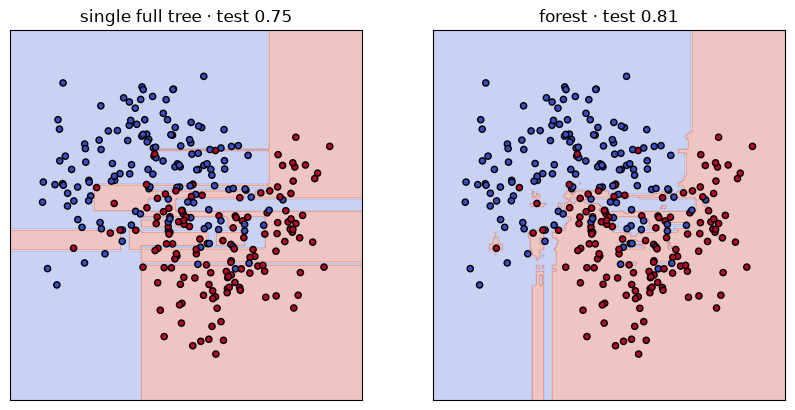

In [3]:
Xn, yn = moons(n_samples=400, noise=0.4, seed=SEED)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.3, random_state=SEED)
tree_n = DecisionTreeClassifier(max_depth=None).fit(Xn_tr, yn_tr)
forest_n = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED).fit(Xn_tr, yn_tr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
plot_decision_boundary(tree_n, Xn_tr, yn_tr, ax=axes[0], resolution=RES,
                       title=f'single full tree · test {accuracy(yn_te, tree_n.predict(Xn_te)):.2f}')
plot_decision_boundary(forest_n, Xn_tr, yn_tr, ax=axes[1], resolution=RES,
                       title=f'forest · test {accuracy(yn_te, forest_n.predict(Xn_te)):.2f}')
save_figure(fig, '06_tree_vs_forest_noisy')

## The numbers, side by side
XOR: the greedy stump vs the forest (fit accuracy). Noisy moons: a single full tree vs the forest (held-out test accuracy).

{'xor_clean_fit': {'greedy_stump': 0.54, 'forest': 1.0}, 'noisy_moons_test': {'single_full_tree': 0.75, 'forest': 0.8083333333333333}}


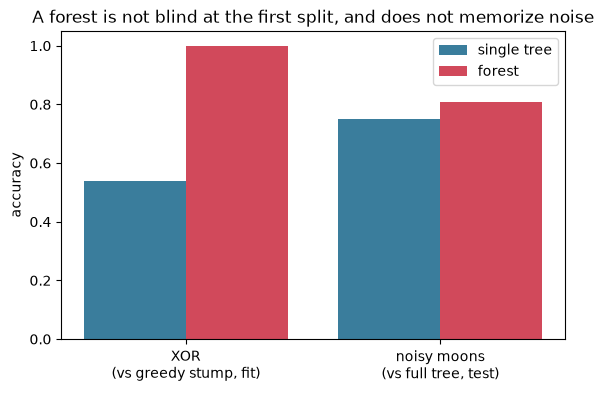

In [4]:
xor_cmp = {'greedy_stump': float(accuracy(yx, tree.predict(Xx))),
           'forest': float(accuracy(yx, forest.predict(Xx)))}
moons_cmp = {'single_full_tree': float(accuracy(yn_te, tree_n.predict(Xn_te))),
             'forest': float(accuracy(yn_te, forest_n.predict(Xn_te)))}
comparison = {'xor_clean_fit': xor_cmp, 'noisy_moons_test': moons_cmp}

labels = ['XOR\n(vs greedy stump, fit)', 'noisy moons\n(vs full tree, test)']
single = [xor_cmp['greedy_stump'], moons_cmp['single_full_tree']]
ensemble = [xor_cmp['forest'], moons_cmp['forest']]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x - 0.2, single, 0.4, label='single tree', color='#3a7d9c')
ax.bar(x + 0.2, ensemble, 0.4, label='forest', color='#d1495b')
ax.set_xticks(x, labels)
ax.set(ylabel='accuracy', title='A forest is not blind at the first split, and does not memorize noise')
ax.legend()
save_figure(fig, '06_accuracy_comparison')
save_json(comparison, '06_tree_vs_forest')
print(comparison)

## The hyperparameters, now that you know the algorithm they control

In [5]:
guide = {
    'max_depth': 'How many questions deep the greedy recursion may go. Lower = coarser staircase = more regularization.',
    'min_samples_leaf': 'Refuse a split that would leave a tiny leaf. Directly blocks the wrap-around-each-point memorization.',
    'min_samples_split': 'Do not even search for a split in a node smaller than this. A cheaper cousin of min_samples_leaf.',
    'criterion': 'The impurity scored at each split: gini or entropy for classification, mse for regression. Choice rarely matters much (notebook 03).',
    'ccp_alpha': 'Cost-complexity pruning strength applied after growth. Larger prunes more (notebook 05).',
}
for k, v in guide.items():
    print(f'- {k}: {v}')
save_json(guide, '06_hyperparameter_guide')

- max_depth: How many questions deep the greedy recursion may go. Lower = coarser staircase = more regularization.
- min_samples_leaf: Refuse a split that would leave a tiny leaf. Directly blocks the wrap-around-each-point memorization.
- min_samples_split: Do not even search for a split in a node smaller than this. A cheaper cousin of min_samples_leaf.
- criterion: The impurity scored at each split: gini or entropy for classification, mse for regression. Choice rarely matters much (notebook 03).
- ccp_alpha: Cost-complexity pruning strength applied after growth. Larger prunes more (notebook 05).


PosixPath('/workspaces/decision_trees_101/outputs/data/06_hyperparameter_guide.json')

## A parting caution: a tree's own importances are biased
Add a pure-noise feature to the moons. Impurity-based importance (Gini reduction) still hands it credit, because a continuous noise column offers many thresholds to overfit; permutation importance, which measures real predictive value, does not.

PosixPath('/workspaces/decision_trees_101/outputs/data/06_importance_caveat.json')

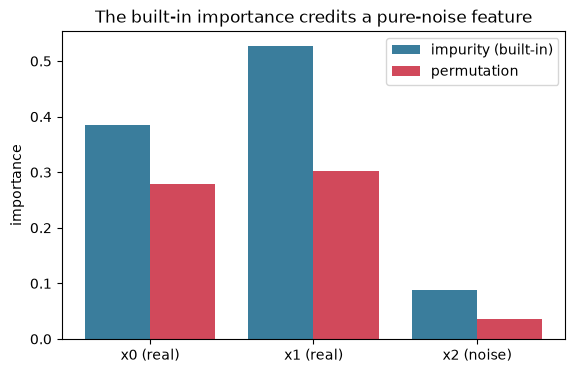

In [6]:
Xm, ym = moons(n_samples=600, noise=0.2, seed=SEED)
rng = np.random.default_rng(SEED)
X_aug = np.column_stack([Xm, rng.normal(size=len(ym))])   # feature 2 is pure noise
names = ['x0 (real)', 'x1 (real)', 'x2 (noise)']

rf = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED).fit(X_aug, ym)
impurity_imp = rf.feature_importances_
perm = permutation_importance(rf, X_aug, ym, n_repeats=10, random_state=SEED)
perm_imp = perm.importances_mean

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(names))
ax.bar(x - 0.2, impurity_imp, 0.4, label='impurity (built-in)', color='#3a7d9c')
ax.bar(x + 0.2, perm_imp, 0.4, label='permutation', color='#d1495b')
ax.set_xticks(x, names)
ax.set(ylabel='importance', title='The built-in importance credits a pure-noise feature')
ax.legend()
save_figure(fig, '06_importances')
save_json({'feature_names': names,
           'impurity_importance': impurity_imp.tolist(),
           'permutation_importance': perm_imp.tolist()}, '06_importance_caveat')

## Takeaway — and the handoff
Averaging many trees reduces the single greedy tree's variance, and randomness explores splits greediness would miss: the forest solves XOR and stops memorizing. You now hold the base learner and its failures from the inside — which is exactly where **ensembles_101** begins. Every knob you tune there is a decision about the little algorithm in these six notebooks.